# 03 — Backtest: Fair Value Mean Reversion

In [1]:
# Notebook is location-agnostic: walk up to find the project root
# (the dir containing pyproject.toml) and chdir there before any imports.
import os, pathlib
_p = pathlib.Path.cwd()
while _p != _p.parent and not (_p / "pyproject.toml").exists():
    _p = _p.parent
if (_p / "pyproject.toml").exists():
    os.chdir(_p)
del _p


In [2]:
from datetime import datetime, timedelta, timezone
from src.layer1_research.backtesting.config import BacktestConfig
from src.layer1_research.backtesting.runner import BacktestRunner
from src.layer1_research.backtesting.strategies.examples.fair_value_mean_reversion import (
    FairValueMeanReversionStrategy,
)
from src.layer1_research.backtesting.execution.fill_model import PredictionMarketFillConfig
from src.layer1_research.backtesting.reporting.cli_report import print_report

## Config

In [3]:
config = BacktestConfig(
    catalog_path="data/catalog",
    start=datetime(2024, 6, 1, tzinfo=timezone.utc),
    end=datetime(2024, 9, 1, tzinfo=timezone.utc),
    strategy_name="fair_value_mr",
    starting_capital=10_000.0,
    data_mode="trade",
    fee_rate_bps=100,
    position_sizer="fixed_fractional",
    fill_model=PredictionMarketFillConfig(base_spread_pct=0.04),
    strategy_params={"lookback_trades": 20, "entry_threshold": 0.05},
)

## Run

In [4]:
result = BacktestRunner(config).run(FairValueMeanReversionStrategy)
print_report(result.metrics())

2024-08-31T23:59:49.000000000Z [WARN] BACKTESTER-001.FairValueMeanReversionStrategy: The `Strategy.on_stop` handler was called when not overridden. It's expected that any actions required when stopping the strategy occur here, such as unsubscribing from data



  Backtest results
  Total Return:              -33.20%
  Sharpe Ratio:                 nan
  Sortino Ratio:                nan
  Max Drawdown:                0.00%
  Calmar Ratio:                0.00
  Total Trades:                 183
  Win Rate:                   11.3%
  Avg Win:             $       1.06
  Avg Loss:            $     -26.79
  Profit Factor:               0.01
  Avg Hold Time:       16 days 08:25:41.525423728
  Total Fees:          $     397.54
  Fee Drag:                   10.5%
  Avg Slippage:               0.0 bps
  Avg Edge @ Order:          0.0334
  Edge Realization:            0.00
  Top 5 markets by P&L:
    2174263314346390629056905015582624153306 $      -70  (7 trades, win 0%)
    8758495535924524640495212808245189728777 $      -77  (9 trades, win 0%)
    4833104333661288389093875950949315923475 $      -77  (4 trades, win 0%)
    6923692362007769102708394687114864697201 $   -1,029  (49 trades, win 0%)
    4389801918844310925454401164414109574832 $   -1,346  

## Plots

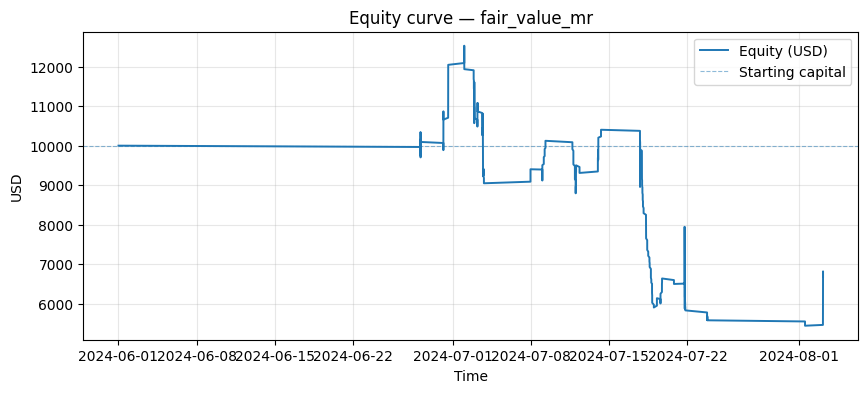

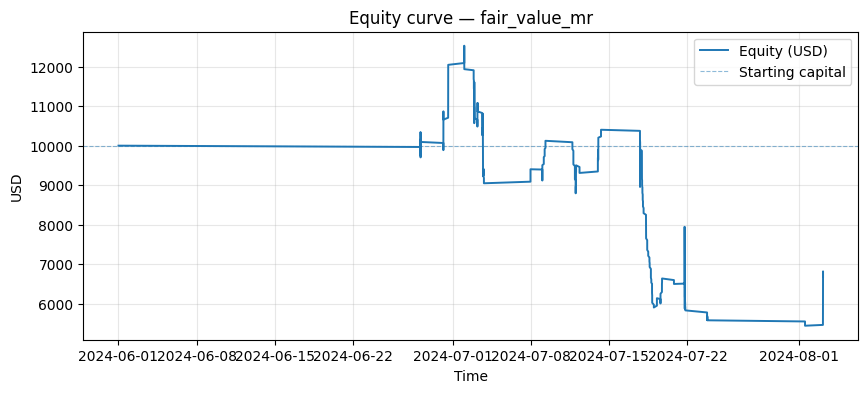

In [5]:
result.plot_equity_curve()

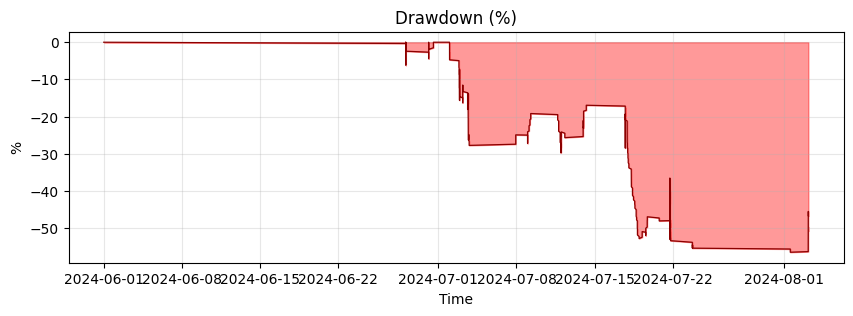

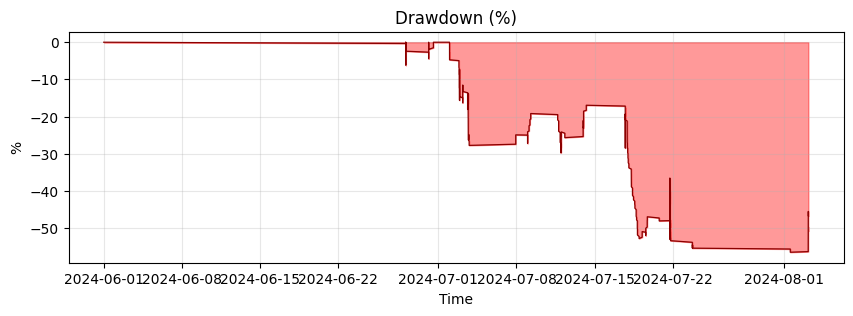

In [6]:
result.plot_drawdown()

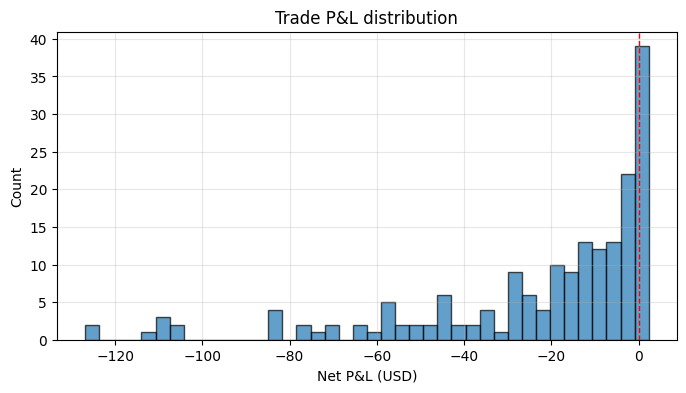

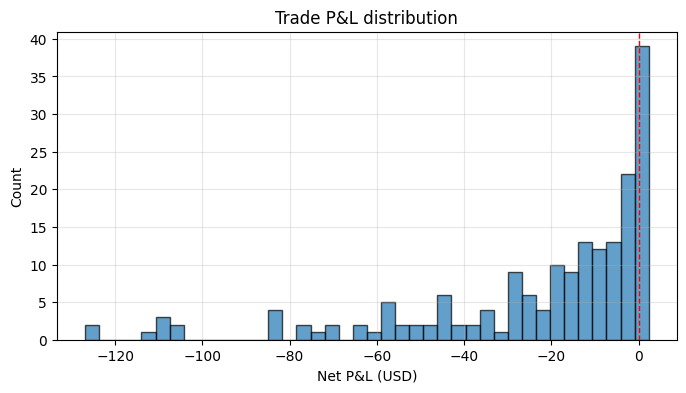

In [7]:
result.plot_pnl_histogram()

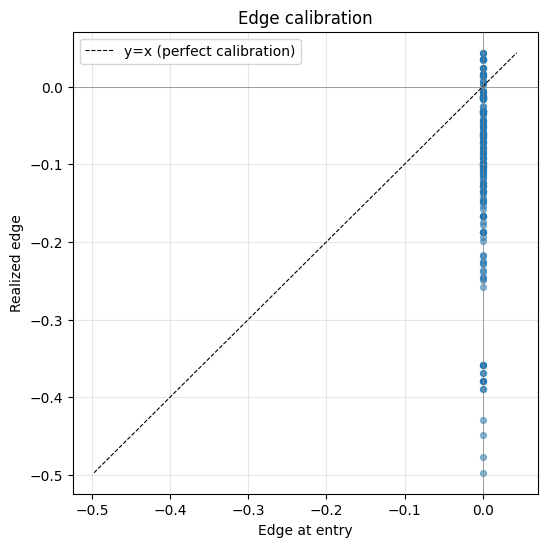

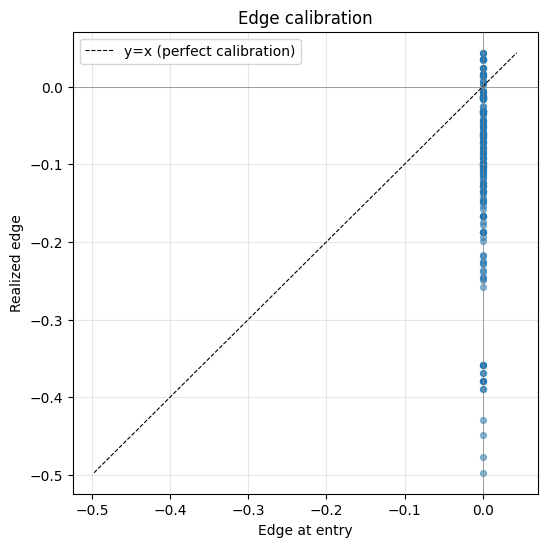

In [8]:
result.plot_edge_calibration()

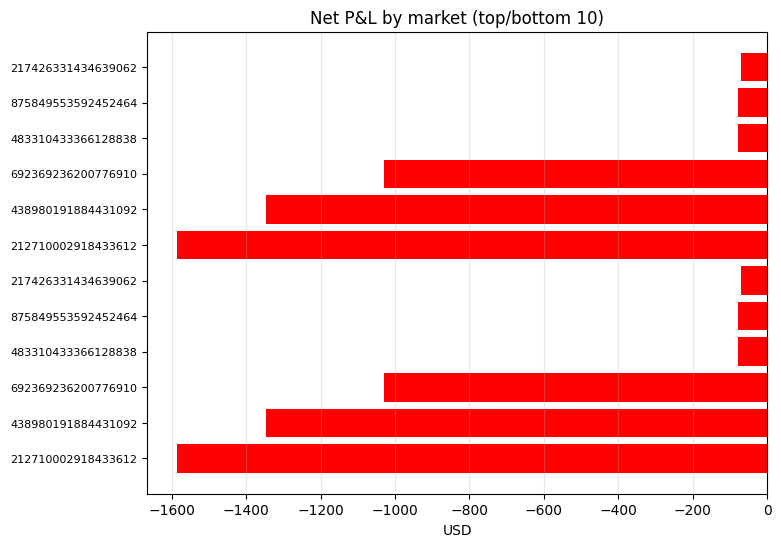

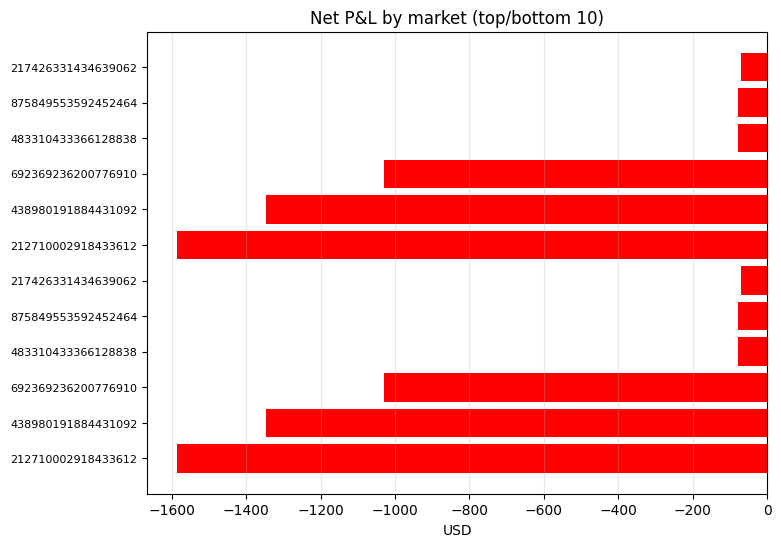

In [9]:
result.plot_per_market_pnl()

## Inspect trades and signals

In [10]:
result.trades.head(20)

,instrument_id,direction,entry_ts,exit_ts,entry_price,exit_price,size,fees,gross_pnl,net_pnl,edge_at_entry,slippage_bps,signal_confidence,realized_edge
0,2127100029184336124920906570609716702908306732...,SHORT,2024-06-30 02:58:05+00:00,2024-07-08 23:51:46+00:00,0.084006,0.17,40.5,19.53,-3.482767,-23.012767,0.0,0.0,0.0,-0.085994
1,2127100029184336124920906570609716702908306732...,SHORT,2024-06-30 02:58:05+00:00,2024-07-08 23:51:46+00:00,0.084006,0.19,202.5,0.38,-21.463835,-21.843835,0.0,0.0,0.0,-0.105994
2,2127100029184336124920906570609716702908306732...,SHORT,2024-06-30 02:58:05+00:00,2024-07-08 23:51:46+00:00,0.084006,0.22,810.0,1.78,-110.155339,-111.935339,0.0,0.0,0.0,-0.135994
3,2127100029184336124920906570609716702908306732...,SHORT,2024-06-30 02:58:05+00:00,2024-07-08 23:51:46+00:00,0.084006,0.23,253.0,0.58,-36.936544,-37.516544,0.0,0.0,0.0,-0.145994
4,2127100029184336124920906570609716702908306732...,SHORT,2024-06-30 02:58:05+00:00,2024-07-13 23:35:37+00:00,0.088524,0.14,34.6,1.67,-1.781065,-3.451065,0.0,0.0,0.0,-0.051476
5,2127100029184336124920906570609716702908306732...,SHORT,2024-06-30 02:58:05+00:00,2024-07-13 23:35:37+00:00,0.088524,0.16,172.8,0.28,-12.351031,-12.631031,0.0,0.0,0.0,-0.071476
6,2127100029184336124920906570609716702908306732...,SHORT,2024-06-30 02:58:05+00:00,2024-07-13 23:35:37+00:00,0.088524,0.19,691.0,1.31,-70.119830,-71.429830,0.0,0.0,0.0,-0.101476
7,2127100029184336124920906570609716702908306732...,SHORT,2024-06-30 02:58:05+00:00,2024-07-13 23:35:37+00:00,0.088524,0.20,357.0,0.71,-39.796888,-40.506888,0.0,0.0,0.0,-0.111476
8,2127100029184336124920906570609716702908306732...,SHORT,2024-06-30 02:58:05+00:00,2024-07-13 23:49:01+00:00,0.088524,0.18,455.7,0.82,-41.685557,-42.505557,0.0,0.0,0.0,-0.091476
9,2127100029184336124920906570609716702908306732...,SHORT,2024-06-30 02:58:05+00:00,2024-07-13 23:49:01+00:00,0.088524,0.17,640.0,1.09,-52.144561,-53.234561,0.0,0.0,0.0,-0.081476


In [11]:
result.signals.head(20)

,instrument_id,direction,market_price,confidence,target_price,size,client_order_id,edge_at_order
ts,,,,,,,,
2024-06-28 01:32:08+00:00,4833104333661288389093875950949315923475504897...,BUY,0.31,0.5510,0.3610,554.016620,O-20240628-013208-001-000-1,0.2410
2024-06-28 01:32:08+00:00,2174263314346390629056905015582624153306727273...,SELL,0.69,0.5545,0.6355,307.129504,O-20240628-013208-001-000-2,0.2445
2024-06-28 01:32:28+00:00,2174263314346390629056905015582624153306727273...,SELL,0.69,0.5505,0.6395,311.242846,O-20240628-013228-001-000-3,0.2405
2024-06-28 01:47:22+00:00,4833104333661288389093875950949315923475504897...,BUY,0.26,0.5750,0.3350,606.185075,O-20240628-014722-001-000-4,0.3150
2024-06-28 01:47:22+00:00,2174263314346390629056905015582624153306727273...,SELL,0.71,0.5585,0.6515,305.331696,O-20240628-014722-001-000-5,0.2685
2024-06-28 01:48:30+00:00,2174263314346390629056905015582624153306727273...,SELL,0.71,0.5530,0.6570,308.887976,O-20240628-014830-001-000-6,0.2630
2024-06-28 01:56:17+00:00,4833104333661288389093875950949315923475504897...,BUY,0.26,0.5575,0.3175,651.595591,O-20240628-015617-001-000-7,0.2975
2024-06-28 01:56:17+00:00,4833104333661288389093875950949315923475504897...,BUY,0.26,0.5530,0.3130,645.858147,O-20240628-015617-001-000-8,0.2930
2024-06-28 01:56:17+00:00,4833104333661288389093875950949315923475504897...,BUY,0.26,0.5505,0.3105,637.961353,O-20240628-015617-001-000-9,0.2905


## Optional: log to MLflow

In [12]:
# run_id = result.to_mlflow(run_name=f"fair_value_mr_{config.start.date()}_{config.end.date()}")
# print(f"MLflow run: {run_id}")